All imports OK
Data dir : /kaggle/input/datasets/mrwellsdavid/unsw-nb15/
Model dir: /kaggle/working/models/
Files in data dir: ['UNSW_NB15_testing-set.csv', 'UNSW-NB15_1.csv', 'UNSW_NB15_training-set.csv', 'UNSW-NB15_LIST_EVENTS.csv', 'UNSW-NB15_4.csv', 'UNSW-NB15_3.csv', 'UNSW-NB15_2.csv', 'NUSW-NB15_features.csv']
Loading raw CSVs…
  Loaded file 1: (700001, 49)
  Loaded file 2: (700001, 49)
  Loaded file 3: (700001, 49)
  Loaded file 4: (440044, 49)
Cached.

Dataset shape: (2540047, 49)
Memory usage : 1247.6 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2540047 entries, 0 to 2540046
Data columns (total 49 columns):
 #   Column            Dtype  
---  ------            -----  
 0   srcip             object 
 1   sport             Int32  
 2   dstip             object 
 3   dsport            Int32  
 4   proto             object 
 5   state             object 
 6   dur               float32
 7   sbytes            float32
 8   dbytes            float32
 9   sttl              floa

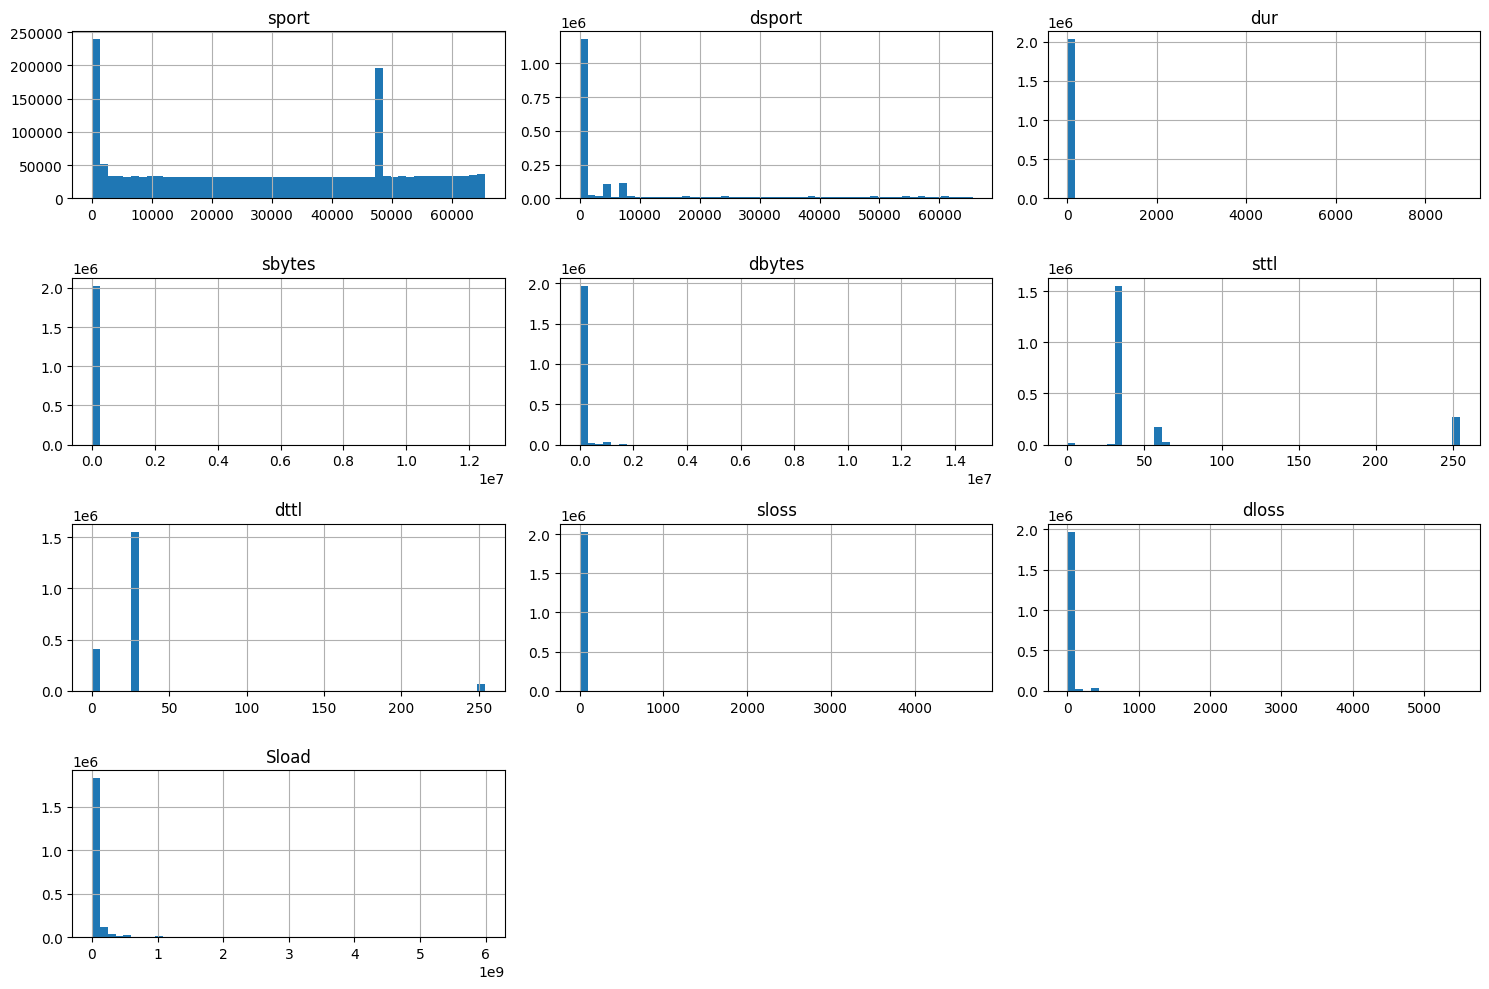

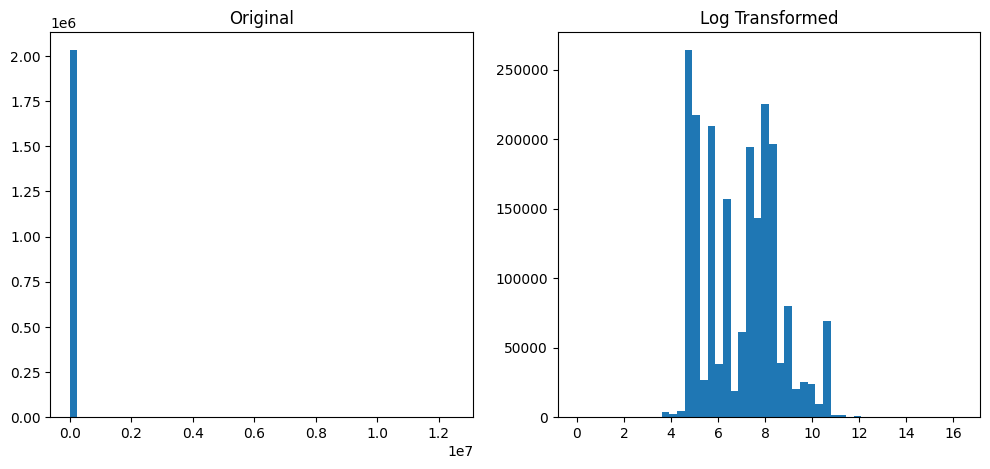

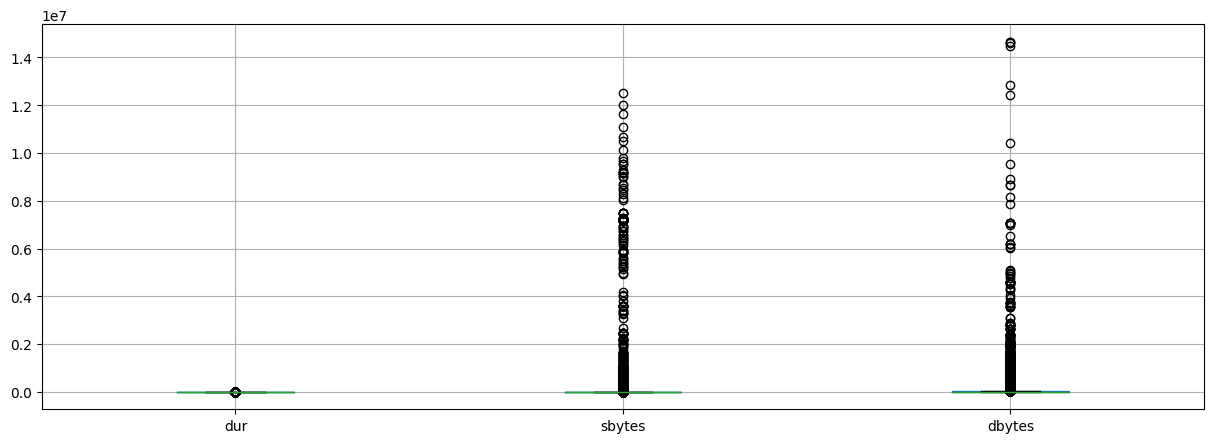

dur                 634.454956
trans_depth         157.109756
sbytes              141.875763
sloss                114.68441
Djit                 98.542603
Sjit                 47.962151
ackdat               44.675053
synack               41.077576
tcprtt               33.371475
Dintpkt              25.093843
is_sm_ips_ports      24.705366
Spkts                23.487108
Sintpkt              18.761297
res_bdy_len          18.058895
ct_flw_http_mthd     16.044828
dtype: Float64
Skewed columns transformed : 36
X_train shape after drop   : (2032037, 46)
✅ OrdinalEncoder saved.
✅ Subnet encoders saved.
src_unique_dst — train max : 12
Fallback value (median)    : 10
train  →  NaN: 0  |  Inf: 0
test  →  NaN: 0  |  Inf: 0
Final feature count : 59
X_train shape       : (2032037, 59)
X_test  shape       : (508010, 59)

Final columns:
['proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'sme

In [1]:
# =============================================================================
# IDS Pipeline — UNSW-NB15
# Phases 1-11: Load → Clean → Split → EDA → Feature Engineering →
#              Encode → IP Features → Flow Features → Time-Based Validation
# =============================================================================

import gc
import os
import ipaddress
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score,
    precision_recall_curve, f1_score
)
import joblib

import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE

print('All imports OK')

# =============================================================================
# Phase 1 — Paths
# =============================================================================
DATA_DIR  = "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/"
MODEL_DIR = '/kaggle/working/models/'
CACHE     = '/kaggle/working/combined_cache.parquet'

os.makedirs(MODEL_DIR, exist_ok=True)

print(f'Data dir : {DATA_DIR}')
print(f'Model dir: {MODEL_DIR}')
print(f'Files in data dir: {os.listdir(DATA_DIR)}')

# =============================================================================
# Phase 2 — Load & Merge
# =============================================================================
feature_names = [
    'srcip','sport','dstip','dsport','proto','state','dur','sbytes','dbytes',
    'sttl','dttl','sloss','dloss','service','Sload','Dload','Spkts','Dpkts',
    'swin','dwin','stcpb','dtcpb','smeansz','dmeansz','trans_depth',
    'res_bdy_len','Sjit','Djit','Stime','Ltime','Sintpkt','Dintpkt',
    'tcprtt','synack','ackdat','is_sm_ips_ports','ct_state_ttl',
    'ct_flw_http_mthd','is_ftp_login','ct_ftp_cmd','ct_srv_src',
    'ct_srv_dst','ct_dst_ltm','ct_src_ltm','ct_src_dport_ltm',
    'ct_dst_sport_ltm','ct_dst_src_ltm','attack_cat','Label'
]

dtype_map = {
    'dur': 'float32', 'sbytes': 'float32', 'dbytes': 'float32',
    'sttl': 'float32', 'dttl': 'float32', 'sloss': 'float32',
    'dloss': 'float32', 'Sload': 'float32', 'Dload': 'float32',
    'Spkts': 'float32', 'Dpkts': 'float32', 'swin': 'float32',
    'dwin': 'float32', 'stcpb': 'float32', 'dtcpb': 'float32',
    'smeansz': 'float32', 'dmeansz': 'float32', 'trans_depth': 'float32',
    'res_bdy_len': 'float32', 'Sjit': 'float32', 'Djit': 'float32',
    'Sintpkt': 'float32', 'Dintpkt': 'float32', 'tcprtt': 'float32',
    'synack': 'float32', 'ackdat': 'float32', 'is_sm_ips_ports': 'float32',
    'ct_state_ttl': 'float32', 'ct_flw_http_mthd': 'float32',
    'is_ftp_login': 'float32', 'ct_ftp_cmd': 'float32',
    'ct_srv_src': 'float32', 'ct_srv_dst': 'float32',
    'ct_dst_ltm': 'float32', 'ct_src_ltm': 'float32',
    'ct_src_dport_ltm': 'float32', 'ct_dst_sport_ltm': 'float32',
    'ct_dst_src_ltm': 'float32', 'Label': 'int8'
}

def load_and_merge():
    dfs = []
    for i in range(1, 5):
        path = f'{DATA_DIR}UNSW-NB15_{i}.csv'
        df = pd.read_csv(path, header=None, low_memory=False)
        df.columns = feature_names
        for col, dtype in dtype_map.items():
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').astype(dtype)
        for col in ['sport', 'dsport']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int32')
        dfs.append(df)
        print(f'  Loaded file {i}: {df.shape}')
    combined = pd.concat(dfs, ignore_index=True)
    del dfs
    gc.collect()
    return combined

if os.path.exists(CACHE):
    print('Loading from cache…')
    combined_df = pd.read_parquet(CACHE)
else:
    print('Loading raw CSVs…')
    combined_df = load_and_merge()
    combined_df.to_parquet(CACHE, index=False)
    print('Cached.')

print(f'\nDataset shape: {combined_df.shape}')
print(f'Memory usage : {combined_df.memory_usage(deep=True).sum()/1e6:.1f} MB')
combined_df.info()

# =============================================================================
# Phase 3 — Cleaning
# =============================================================================
combined_df['attack_cat'] = (
    combined_df['attack_cat']
    .astype(str).str.strip()
    .replace({'nan': 'Normal', 'NaN': 'Normal', '': 'Normal'})
)

combined_df['ct_flw_http_mthd'] = combined_df['ct_flw_http_mthd'].fillna(0).astype('float32')
combined_df['is_ftp_login']     = combined_df['is_ftp_login'].fillna(0).astype('float32')
combined_df['ct_ftp_cmd']       = combined_df['ct_ftp_cmd'].fillna(0).astype('float32')

remaining_nulls = combined_df.isnull().sum().sum()
print(f'Remaining nulls: {remaining_nulls}')

print('\nBinary class distribution:')
print(combined_df['Label'].value_counts(normalize=True)
      .rename({0: 'Normal', 1: 'Attack'}).map('{:.1%}'.format))

print('\nAttack categories:')
print(combined_df['attack_cat'].value_counts())

# =============================================================================
# Phase 4 — Train / Test Split
# =============================================================================
X    = combined_df.drop(columns=['Label', 'attack_cat'])
y    = combined_df['Label'].astype('int8')
y_mc = combined_df['attack_cat']

X_train, X_test, y_train, y_test, y_train_mc, y_test_mc = train_test_split(
    X, y, y_mc, test_size=0.20, stratify=y, random_state=42
)

del combined_df, X
gc.collect()

print(f'Train : {X_train.shape}  |  Attack rate: {y_train.mean():.2%}')
print(f'Test  : {X_test.shape}   |  Attack rate: {y_test.mean():.2%}')

# =============================================================================
# Phase 5a — EDA
# =============================================================================
num_cols = X_train.select_dtypes(include=['int32', 'float32']).columns
X_train[num_cols[:10]].hist(bins=50, figsize=(15, 10))
plt.tight_layout()
plt.show()

col = 'sbytes'
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.hist(X_train[col], bins=50); plt.title('Original')
plt.subplot(1, 2, 2); plt.hist(np.log1p(X_train[col]), bins=50); plt.title('Log Transformed')
plt.show()

plt.figure(figsize=(15, 5))
X_train[['dur', 'sbytes', 'dbytes']].boxplot()
plt.show()

skewness = X_train.skew(numeric_only=True).sort_values(ascending=False)
print(skewness.head(15))

# =============================================================================
# Phase 5b — duration_time
# =============================================================================
X_train['duration_time'] = X_train['Ltime'] - X_train['Stime']
X_test['duration_time']  = X_test['Ltime']  - X_test['Stime']

# =============================================================================
# Phase 5c — Log-transform skewed columns
# =============================================================================
skewness    = X_train.skew(numeric_only=True)
skewed_cols = skewness[skewness > 1].index

for col in skewed_cols:
    X_train[col] = np.log1p(X_train[col])
for col in skewed_cols:
    X_test[col] = np.log1p(X_test[col])

X_train['duration_time'] = X_train['duration_time'].astype('float32')
X_test['duration_time']  = X_test['duration_time'].astype('float32')

X_train = X_train.drop(columns=['Stime', 'Ltime'])
X_test  = X_test.drop(columns=['Stime', 'Ltime'])

print(f'Skewed columns transformed : {len(skewed_cols)}')
print(f'X_train shape after drop   : {X_train.shape}')

# =============================================================================
# Phase 6 — Encode categoricals
# =============================================================================
CATEGORICAL_COLS = ['proto', 'state', 'service']

for col in CATEGORICAL_COLS:
    X_train[col] = X_train[col].astype(str).str.strip().str.lower()
    X_test[col]  = X_test[col].astype(str).str.strip().str.lower()

ord_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[CATEGORICAL_COLS] = ord_encoder.fit_transform(X_train[CATEGORICAL_COLS]).astype('int32')
X_test[CATEGORICAL_COLS]  = ord_encoder.transform(X_test[CATEGORICAL_COLS]).astype('int32')

joblib.dump(ord_encoder, 'ordinal_encoder.joblib')
print('✅ OrdinalEncoder saved.')

# =============================================================================
# Phase 7 — IP Feature Engineering
# =============================================================================
def extract_ip_features(ip):
    try:
        ip_obj = ipaddress.ip_address(ip)
        return {
            'is_private':   int(ip_obj.is_private),
            'is_global':    int(ip_obj.is_global),
            'is_multicast': int(ip_obj.is_multicast),
            'version':      ip_obj.version
        }
    except:
        return {'is_private': 0, 'is_global': 0, 'is_multicast': 0, 'version': 0}

for split, df in [('train', X_train), ('test', X_test)]:
    src_feat = df['srcip'].apply(extract_ip_features).apply(pd.Series)
    dst_feat = df['dstip'].apply(extract_ip_features).apply(pd.Series)
    src_feat.columns = ['src_' + c for c in src_feat.columns]
    dst_feat.columns = ['dst_' + c for c in dst_feat.columns]
    if split == 'train':
        X_train = pd.concat([X_train, src_feat, dst_feat], axis=1)
    else:
        X_test  = pd.concat([X_test,  src_feat, dst_feat], axis=1)

def get_subnet(ip):
    try:
        ip_obj = ipaddress.ip_address(ip)
        if ip_obj.version == 4:
            return '.'.join(ip.split('.')[:2])
        else:
            return ip_obj.exploded[:9]
    except:
        return 'unknown'

X_train['src_subnet'] = X_train['srcip'].apply(get_subnet)
X_train['dst_subnet'] = X_train['dstip'].apply(get_subnet)
X_test['src_subnet']  = X_test['srcip'].apply(get_subnet)
X_test['dst_subnet']  = X_test['dstip'].apply(get_subnet)

subnet_encoders = {}
for col in ['src_subnet', 'dst_subnet']:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    subnet_encoders[col] = le
    X_test[col] = X_test[col].map(
        lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
    )

joblib.dump(subnet_encoders, 'subnet_encoders.joblib')
print('✅ Subnet encoders saved.')

src_counts = X_train['srcip'].value_counts()
dst_counts = X_train['dstip'].value_counts()
joblib.dump(src_counts, 'src_freq_map.joblib')
joblib.dump(dst_counts, 'dst_freq_map.joblib')

X_train['src_freq'] = np.log1p(X_train['srcip'].map(src_counts))
X_train['dst_freq'] = np.log1p(X_train['dstip'].map(dst_counts))
X_test['src_freq']  = np.log1p(X_test['srcip'].map(src_counts).fillna(0))
X_test['dst_freq']  = np.log1p(X_test['dstip'].map(dst_counts).fillna(0))

train_src_unique = X_train.groupby('srcip')['dstip'].nunique()
median_unique    = int(train_src_unique.median())

X_train['src_unique_dst'] = X_train['srcip'].map(train_src_unique).astype('float32')
X_test['src_unique_dst']  = X_test['srcip'].map(train_src_unique).fillna(median_unique).astype('float32')

print(f'src_unique_dst — train max : {X_train["src_unique_dst"].max():.0f}')
print(f'Fallback value (median)    : {median_unique}')

X_train = X_train.drop(columns=['srcip', 'dstip'])
X_test  = X_test.drop(columns=['srcip', 'dstip'])

# =============================================================================
# Phase 8 — Flow Features
# =============================================================================
def add_flow_features(df):
    df = df.copy()
    df['total_bytes']      = df['sbytes'] + df['dbytes']
    df['byte_ratio']       = np.log1p(df['sbytes']) - np.log1p(df['dbytes'])
    total_pkts             = df['Spkts'] + df['Dpkts']
    df['bytes_per_packet'] = df['total_bytes'] / (total_pkts + 1)
    df['flow_rate']        = df['total_bytes'] / (df['dur'] + 0.001)
    return df

X_train = add_flow_features(X_train)
X_test  = add_flow_features(X_test)

for df in (X_train, X_test):
    df['flow_rate']   = np.log1p(df['flow_rate'])
    df['total_bytes'] = np.log1p(df['total_bytes'])

new_feats = ['total_bytes', 'byte_ratio', 'bytes_per_packet', 'flow_rate']
for name, df in [('train', X_train), ('test', X_test)]:
    nan_count = df[new_feats].isnull().sum().sum()
    inf_count = np.isinf(df[new_feats].values).sum()
    print(f'{name}  →  NaN: {nan_count}  |  Inf: {inf_count}')

# =============================================================================
# Phase 9 — Final Column Drop
# =============================================================================
DROP_COLS = ['sport', 'dsport', 'Stime', 'Ltime', 'srcip', 'dstip']
X_train.drop(columns=DROP_COLS, inplace=True, errors='ignore')
X_test.drop(columns=DROP_COLS,  inplace=True, errors='ignore')

assert list(X_train.columns) == list(X_test.columns), \
    "Column mismatch between train and test!"

print(f'Final feature count : {X_train.shape[1]}')
print(f'X_train shape       : {X_train.shape}')
print(f'X_test  shape       : {X_test.shape}')
print('\nFinal columns:')
print(X_train.columns.tolist())

# =============================================================================
# Phase 10 — SMOTE on random split
# =============================================================================
print('\nApplying SMOTE to random-split training set…')
print(f'Before — Normal: {(y_train==0).sum():,}  |  Attack: {(y_train==1).sum():,}')

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'After  — Normal: {(y_train_bal==0).sum():,}  |  Attack: {(y_train_bal==1).sum():,}')
print(f'Balanced X_train shape: {X_train_bal.shape}')

# =============================================================================
# Phase 11 — Time-Based Validation
# =============================================================================
print('\nLoading cached data for time-based split…')
df_time = pd.read_parquet(CACHE)
df_time['Stime'] = pd.to_numeric(df_time['Stime'], errors='coerce')
df_time = df_time.dropna(subset=['Stime'])
df_time = df_time.sort_values('Stime').reset_index(drop=True)

split_idx  = int(len(df_time) * 0.80)
train_time = df_time.iloc[:split_idx].copy()
test_time  = df_time.iloc[split_idx:].copy()

print(f'Time-based train : {len(train_time):,} rows  '
      f'(Stime {train_time["Stime"].min():.0f} – {train_time["Stime"].max():.0f})')
print(f'Time-based test  : {len(test_time):,} rows  '
      f'(Stime {test_time["Stime"].min():.0f} – {test_time["Stime"].max():.0f})')
print(f'\nAttack rate — train: {train_time["Label"].mean():.2%}  '
      f'| test: {test_time["Label"].mean():.2%}')

# =============================================================================
# Phase 11b — Preprocessing helper for time-based split
# =============================================================================
def preprocess_split(train_df, test_df):
    y_tr = train_df['Label'].astype('int8').values
    y_te = test_df['Label'].astype('int8').values

    def _prep_df(df, src_unique_map=None, freq_src=None, freq_dst=None):
        df = df.drop(columns=['Label', 'attack_cat'], errors='ignore').copy()

        for col, dtype in dtype_map.items():
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').astype(dtype)

        df['ct_flw_http_mthd'] = df['ct_flw_http_mthd'].fillna(0).astype('float32')
        df['is_ftp_login']     = df['is_ftp_login'].fillna(0).astype('float32')
        df['ct_ftp_cmd']       = df['ct_ftp_cmd'].fillna(0).astype('float32')

        for col in CATEGORICAL_COLS:
            df[col] = df[col].astype(str).str.strip().str.lower()

        df['Stime'] = pd.to_numeric(df['Stime'], errors='coerce')
        df['Ltime'] = pd.to_numeric(df['Ltime'], errors='coerce')
        df['duration_time'] = (df['Ltime'] - df['Stime']).astype('float32')

        for col in skewed_cols:
            if col in df.columns:
                df[col] = np.log1p(df[col])

        src_feat = df['srcip'].apply(extract_ip_features).apply(pd.Series)
        dst_feat = df['dstip'].apply(extract_ip_features).apply(pd.Series)
        src_feat.columns = ['src_' + c for c in src_feat.columns]
        dst_feat.columns = ['dst_' + c for c in dst_feat.columns]
        df = pd.concat([df, src_feat, dst_feat], axis=1)

        df['src_subnet'] = df['srcip'].apply(get_subnet)
        df['dst_subnet'] = df['dstip'].apply(get_subnet)

        if freq_src is None:
            freq_src = df['srcip'].value_counts()
        if freq_dst is None:
            freq_dst = df['dstip'].value_counts()
        df['src_freq'] = np.log1p(df['srcip'].map(freq_src).fillna(0))
        df['dst_freq'] = np.log1p(df['dstip'].map(freq_dst).fillna(0))

        if src_unique_map is None:
            src_unique_map = df.groupby('srcip')['dstip'].nunique()
        med = int(src_unique_map.median())
        df['src_unique_dst'] = df['srcip'].map(src_unique_map).fillna(med).astype('float32')

        df = add_flow_features(df)
        df['flow_rate']   = np.log1p(df['flow_rate'])
        df['total_bytes'] = np.log1p(df['total_bytes'])

        df.drop(columns=DROP_COLS, inplace=True, errors='ignore')
        return df, src_unique_map, freq_src, freq_dst

    X_tr_raw, src_map, fsrc, fdst = _prep_df(train_df)
    X_te_raw, _, _, _             = _prep_df(test_df,
                                             src_unique_map=src_map,
                                             freq_src=fsrc,
                                             freq_dst=fdst)

    fitted_encs = {}
    for col in CATEGORICAL_COLS:
        le = LabelEncoder()
        all_train_vals = X_tr_raw[col].astype(str).unique().tolist()
        le.fit(all_train_vals + ['_UNKNOWN_'])
        fitted_encs[col] = le
        known = set(le.classes_)
        X_tr_raw[col] = le.transform(X_tr_raw[col].astype(str))
        X_te_raw[col] = le.transform(
            X_te_raw[col].astype(str).map(lambda v: v if v in known else '_UNKNOWN_')
        )

    for col in ['src_subnet', 'dst_subnet']:
        le = LabelEncoder()
        X_tr_raw[col] = le.fit_transform(X_tr_raw[col].astype(str))
        fitted_encs[col] = le
        known = set(le.classes_)
        X_te_raw[col] = X_te_raw[col].astype(str).map(
            lambda v, le=le: le.transform([v])[0] if v in known else -1
        )

    assert list(X_tr_raw.columns) == list(X_te_raw.columns), \
        "Time-split column mismatch!"

    return X_tr_raw, X_te_raw, y_tr, y_te, fitted_encs


X_tr_time, X_te_time, y_tr_time, y_te_time, enc_time = preprocess_split(
    train_time, test_time
)

del df_time, train_time, test_time
gc.collect()

print(f'\nTime-split — train : {X_tr_time.shape}')
print(f'Time-split — test  : {X_te_time.shape}')
print(f'Attack rate — train: {y_tr_time.mean():.2%}  |  test: {y_te_time.mean():.2%}')

# =============================================================================
# Phase 11c — SMOTE on time-based split
# =============================================================================
# Applied here for a fair comparison with the random-split models.
# Both training sets now have the same 50/50 class balance so the only
# variable between the two regimes is the split strategy itself.
print('\nApplying SMOTE to time-split training set…')
print(f'Before — Normal: {(y_tr_time==0).sum():,}  |  Attack: {(y_tr_time==1).sum():,}')

smote_time = SMOTE(random_state=42)
X_tr_time_bal, y_tr_time_bal = smote_time.fit_resample(X_tr_time, y_tr_time)

print(f'After  — Normal: {(y_tr_time_bal==0).sum():,}  |  Attack: {(y_tr_time_bal==1).sum():,}')
print(f'Balanced X_tr_time shape: {X_tr_time_bal.shape}')

# =============================================================================
# Ready for Training
# =============================================================================
# Random split:
#   X_train_bal / y_train_bal   — SMOTE-balanced (Phase 10)
#   X_train     / y_train       — original unbalanced
#   X_test      / y_test        — held-out test set
#
# Time-based split:
#   X_tr_time_bal / y_tr_time_bal  — SMOTE-balanced (Phase 11c)  ← NEW
#   X_tr_time     / y_tr_time      — original unbalanced
#   X_te_time     / y_te_time      — held-out test set
#
# Multiclass labels:
#   y_train_mc, y_test_mc

print('\n✅ All preprocessing complete — ready for model training.')
print(f'\nRandom split  →  train (bal): {X_train_bal.shape}  |  test: {X_test.shape}')
print(f'Time split    →  train (bal): {X_tr_time_bal.shape}  |  test: {X_te_time.shape}')

  RANDOM SPLIT — XGBoost, LightGBM, Random Forest
  [random] fit: (3195019, 59)  |  val: (355003, 59)

  Training XGBoost [random]…
[0]	validation_0-logloss:0.64562
[50]	validation_0-logloss:0.05318
[100]	validation_0-logloss:0.01658
[150]	validation_0-logloss:0.01247
[200]	validation_0-logloss:0.01115
[250]	validation_0-logloss:0.01032
[300]	validation_0-logloss:0.00977
[350]	validation_0-logloss:0.00935
[400]	validation_0-logloss:0.00903
[450]	validation_0-logloss:0.00874
[500]	validation_0-logloss:0.00850
[550]	validation_0-logloss:0.00829
[600]	validation_0-logloss:0.00812
[650]	validation_0-logloss:0.00797
[700]	validation_0-logloss:0.00787
[750]	validation_0-logloss:0.00776
[800]	validation_0-logloss:0.00767
[850]	validation_0-logloss:0.00759
[900]	validation_0-logloss:0.00752
[950]	validation_0-logloss:0.00745
[999]	validation_0-logloss:0.00738
  Best iteration: 999

  Training LightGBM [random]…
[50]	valid_0's binary_logloss: 0.0517741
[100]	valid_0's binary_logloss: 0.0130104


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  8.2min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed: 12.7min finished


  RF [random] trained.

  TIME SPLIT — XGBoost, LightGBM, Random Forest
  [time] fit: (3257731, 59)  |  val: (361971, 59)

  Training XGBoost [time]…
[0]	validation_0-logloss:0.64549
[50]	validation_0-logloss:0.05229
[100]	validation_0-logloss:0.01554
[150]	validation_0-logloss:0.01144
[200]	validation_0-logloss:0.01017
[250]	validation_0-logloss:0.00935
[300]	validation_0-logloss:0.00876
[350]	validation_0-logloss:0.00834
[400]	validation_0-logloss:0.00805
[450]	validation_0-logloss:0.00780
[500]	validation_0-logloss:0.00759
[550]	validation_0-logloss:0.00742
[600]	validation_0-logloss:0.00726
[650]	validation_0-logloss:0.00712
[700]	validation_0-logloss:0.00699
[750]	validation_0-logloss:0.00689
[800]	validation_0-logloss:0.00679
[850]	validation_0-logloss:0.00670
[900]	validation_0-logloss:0.00661
[950]	validation_0-logloss:0.00654
[999]	validation_0-logloss:0.00646
  Best iteration: 999

  Training LightGBM [time]…
[50]	valid_0's binary_logloss: 0.0508076
[100]	valid_0's binary_log

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  8.7min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed: 13.4min finished


  RF [time] trained.


── RANDOM-SPLIT MODELS  →  evaluated on X_test ──────────────────────

  XGBoost [rand]  |  Random test (X_test)
  Accuracy                  : 0.9944
  ROC-AUC                   : 0.9998
  F1 (weighted)             : 0.9944
  F1 (macro)                : 0.9875
  Precision (Attack class)  : 0.9751
  Recall    (Attack class)  : 0.9811
  F1        (Attack class)  : 0.9781

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    443753
      Attack       0.98      0.98      0.98     64257

    accuracy                           0.99    508010
   macro avg       0.99      0.99      0.99    508010
weighted avg       0.99      0.99      0.99    508010



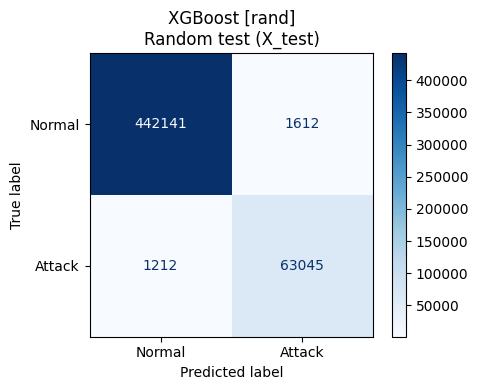


  LightGBM [rand]  |  Random test (X_test)
  Accuracy                  : 0.9952
  ROC-AUC                   : 0.9998
  F1 (weighted)             : 0.9952
  F1 (macro)                : 0.9891
  Precision (Attack class)  : 0.9804
  Recall    (Attack class)  : 0.9815
  F1        (Attack class)  : 0.9809

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    443753
      Attack       0.98      0.98      0.98     64257

    accuracy                           1.00    508010
   macro avg       0.99      0.99      0.99    508010
weighted avg       1.00      1.00      1.00    508010



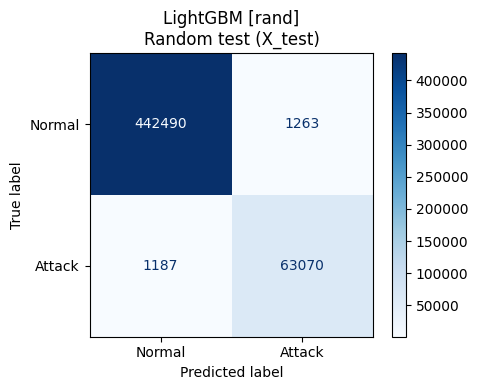

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    2.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    2.2s finished



  RandomForest [rand]  |  Random test (X_test)
  Accuracy                  : 0.9940
  ROC-AUC                   : 0.9998
  F1 (weighted)             : 0.9941
  F1 (macro)                : 0.9866
  Precision (Attack class)  : 0.9672
  Recall    (Attack class)  : 0.9864
  F1        (Attack class)  : 0.9767

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    443753
      Attack       0.97      0.99      0.98     64257

    accuracy                           0.99    508010
   macro avg       0.98      0.99      0.99    508010
weighted avg       0.99      0.99      0.99    508010



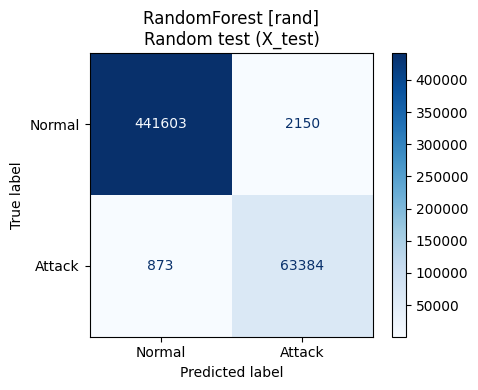

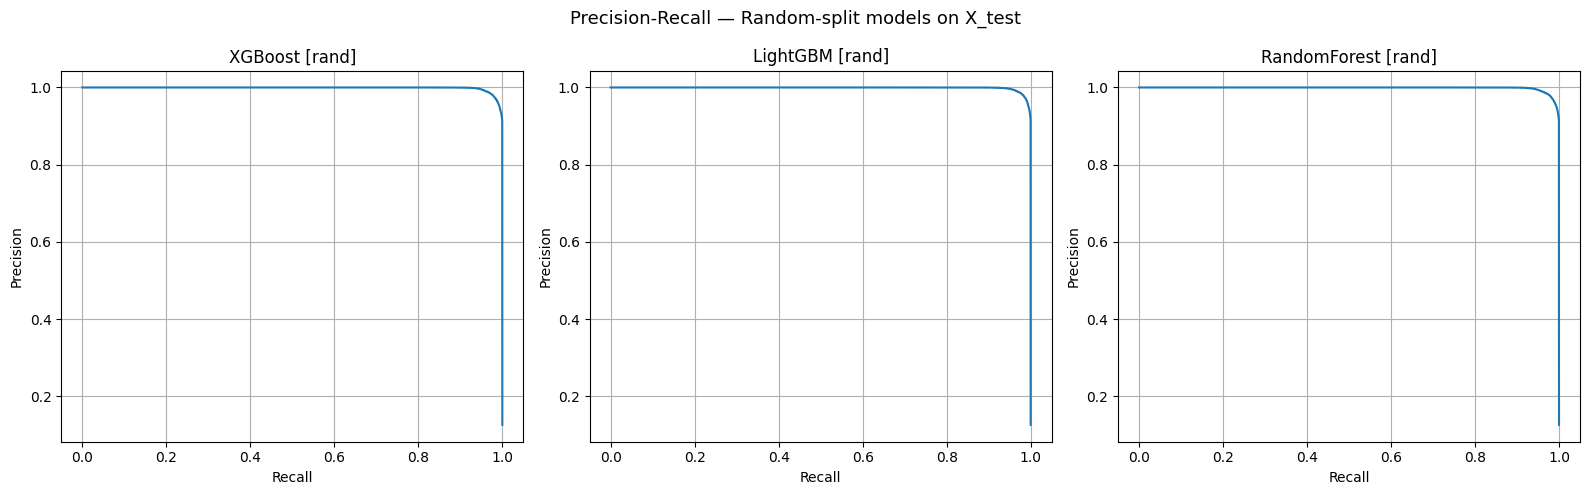



── TIME-SPLIT MODELS  →  evaluated on X_te_time ─────────────────────

  XGBoost [time]  |  Time test (X_te_time)
  Accuracy                  : 0.9877
  ROC-AUC                   : 0.9995
  F1 (weighted)             : 0.9878
  F1 (macro)                : 0.9806
  Precision (Attack class)  : 0.9553
  Recall    (Attack class)  : 0.9830
  F1        (Attack class)  : 0.9689

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    408913
      Attack       0.96      0.98      0.97     99097

    accuracy                           0.99    508010
   macro avg       0.98      0.99      0.98    508010
weighted avg       0.99      0.99      0.99    508010



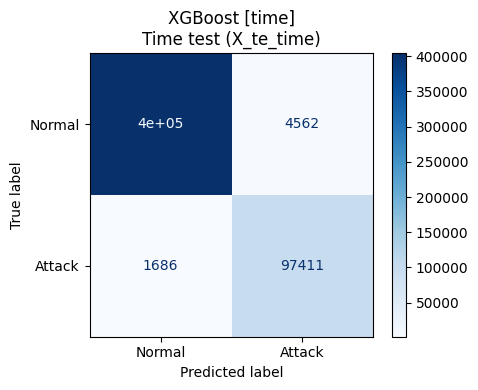


  LightGBM [time]  |  Time test (X_te_time)
  Accuracy                  : 0.9880
  ROC-AUC                   : 0.9995
  F1 (weighted)             : 0.9880
  F1 (macro)                : 0.9810
  Precision (Attack class)  : 0.9583
  Recall    (Attack class)  : 0.9810
  F1        (Attack class)  : 0.9695

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    408913
      Attack       0.96      0.98      0.97     99097

    accuracy                           0.99    508010
   macro avg       0.98      0.99      0.98    508010
weighted avg       0.99      0.99      0.99    508010



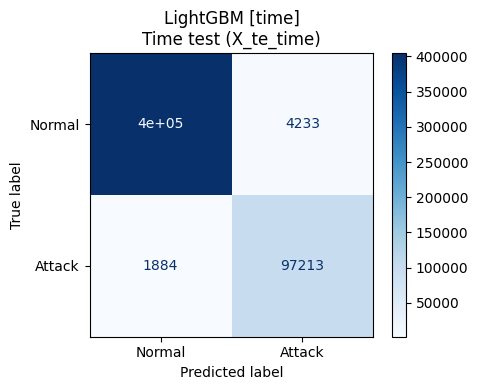

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.3s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    2.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.3s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    2.1s finished



  RandomForest [time]  |  Time test (X_te_time)
  Accuracy                  : 0.9877
  ROC-AUC                   : 0.9990
  F1 (weighted)             : 0.9878
  F1 (macro)                : 0.9807
  Precision (Attack class)  : 0.9507
  Recall    (Attack class)  : 0.9882
  F1        (Attack class)  : 0.9691

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    408913
      Attack       0.95      0.99      0.97     99097

    accuracy                           0.99    508010
   macro avg       0.97      0.99      0.98    508010
weighted avg       0.99      0.99      0.99    508010



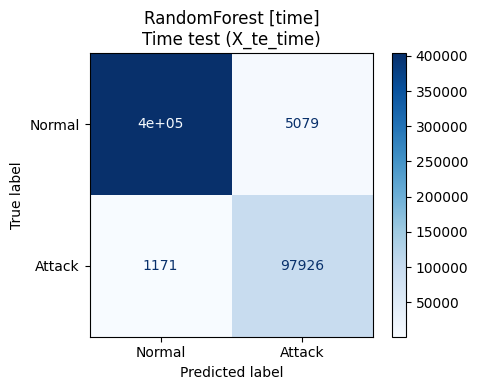

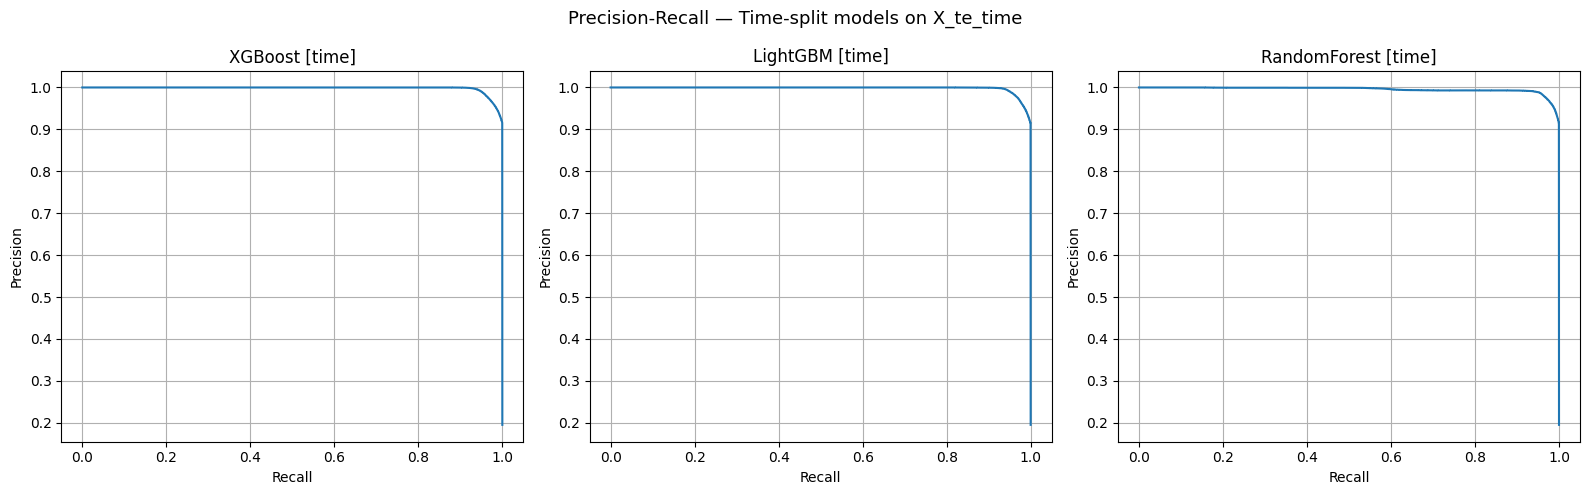



── CROSS-EVAL: random-split models  →  X_te_time ────────────────────

  XGBoost [rand→time]  |  Cross-eval on X_te_time
  Accuracy                  : 0.9863
  ROC-AUC                   : 0.9994
  F1 (weighted)             : 0.9864
  F1 (macro)                : 0.9786
  Precision (Attack class)  : 0.9382
  Recall    (Attack class)  : 0.9952
  F1        (Attack class)  : 0.9658

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99    408913
      Attack       0.94      1.00      0.97     99097

    accuracy                           0.99    508010
   macro avg       0.97      0.99      0.98    508010
weighted avg       0.99      0.99      0.99    508010



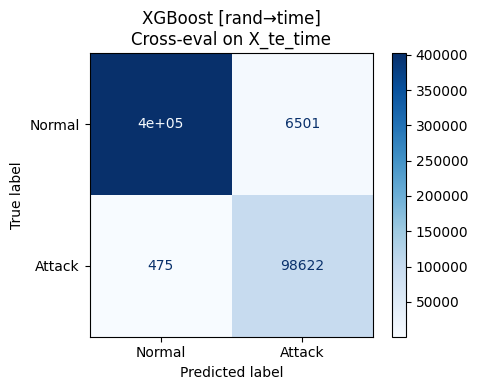


  LightGBM [rand→time]  |  Cross-eval on X_te_time
  Accuracy                  : 0.9895
  ROC-AUC                   : 0.9997
  F1 (weighted)             : 0.9896
  F1 (macro)                : 0.9835
  Precision (Attack class)  : 0.9527
  Recall    (Attack class)  : 0.9954
  F1        (Attack class)  : 0.9736

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    408913
      Attack       0.95      1.00      0.97     99097

    accuracy                           0.99    508010
   macro avg       0.98      0.99      0.98    508010
weighted avg       0.99      0.99      0.99    508010



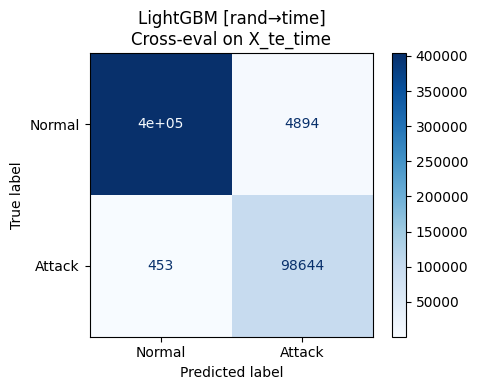

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    2.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    2.1s finished



  RandomForest [rand→time]  |  Cross-eval on X_te_time
  Accuracy                  : 0.9925
  ROC-AUC                   : 0.9998
  F1 (weighted)             : 0.9926
  F1 (macro)                : 0.9882
  Precision (Attack class)  : 0.9688
  Recall    (Attack class)  : 0.9938
  F1        (Attack class)  : 0.9811

              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    408913
      Attack       0.97      0.99      0.98     99097

    accuracy                           0.99    508010
   macro avg       0.98      0.99      0.99    508010
weighted avg       0.99      0.99      0.99    508010



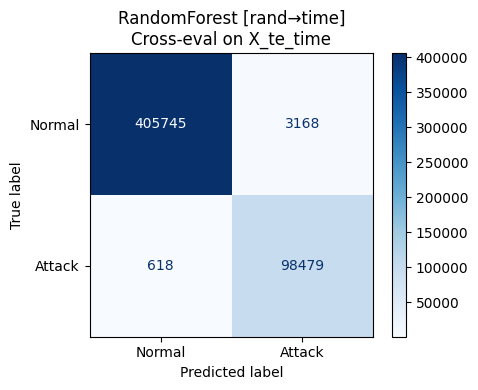



  FULL METRICS SUMMARY TABLE
                   model                   split  accuracy  roc_auc  f1_weighted  f1_macro  precision_w  recall_w  precision_atk  recall_atk  f1_atk
          XGBoost [rand]    Random test (X_test)    0.9944   0.9998       0.9944    0.9875       0.9945    0.9944         0.9751      0.9811  0.9781
         LightGBM [rand]    Random test (X_test)    0.9952   0.9998       0.9952    0.9891       0.9952    0.9952         0.9804      0.9815  0.9809
     RandomForest [rand]    Random test (X_test)    0.9940   0.9998       0.9941    0.9866       0.9941    0.9940         0.9672      0.9864  0.9767
          XGBoost [time]   Time test (X_te_time)    0.9877   0.9995       0.9878    0.9806       0.9879    0.9877         0.9553      0.9830  0.9689
         LightGBM [time]   Time test (X_te_time)    0.9880   0.9995       0.9880    0.9810       0.9881    0.9880         0.9583      0.9810  0.9695
     RandomForest [time]   Time test (X_te_time)    0.9877   0.9990       0

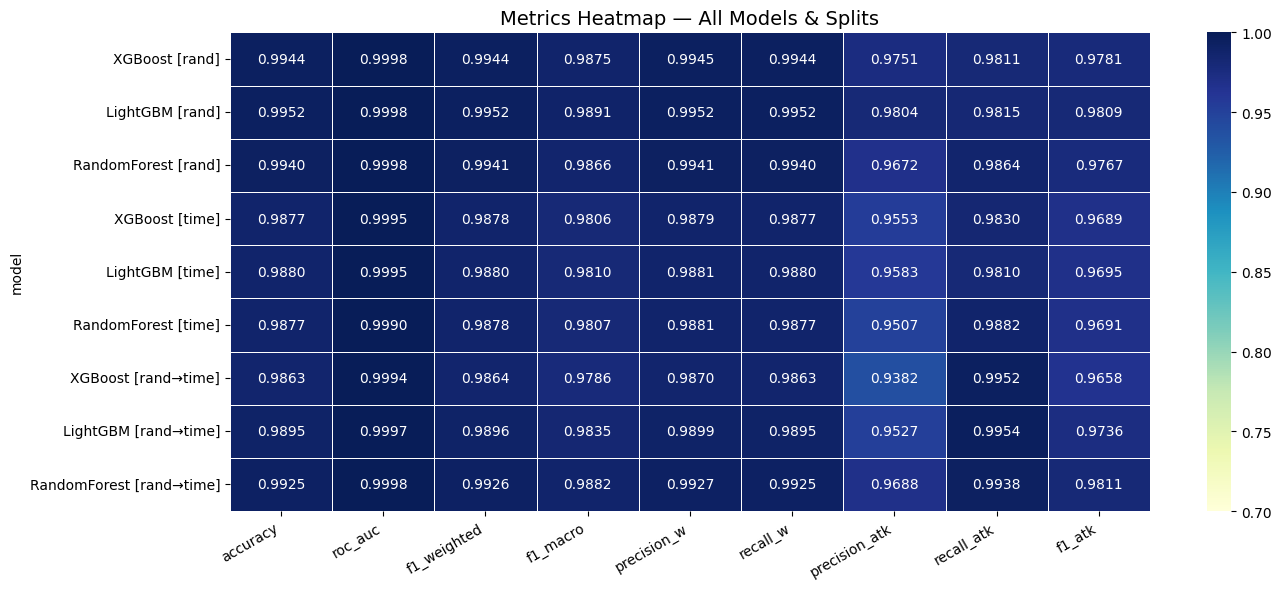


── ROC-AUC Gap Summary ──────────────────────────────────────────────
Algorithm          Rand test   Time test   Cross-eval   Gap (r-t)
-----------------------------------------------------------------
XGBoost               0.9998      0.9995       0.9994     +0.0003
LightGBM              0.9998      0.9995       0.9997     +0.0003
RandomForest          0.9998      0.9990       0.9998     +0.0008

✅ Metrics summary saved → /kaggle/working/models/metrics_summary.csv


── Multiclass training ──────────────────────────────────────────────
Attack categories:
   0: Analysis              train count: 2,145
   1: Backdoor              train count: 1,420
   2: Backdoors             train count: 426
   3: DoS                   train count: 13,059
   4: Exploits              train count: 35,665
   5: Fuzzers               train count: 19,375
   6: Generic               train count: 172,326
   7: Normal                train count: 1,775,011
   8: Reconnaissance        train count: 11,264
   9: S

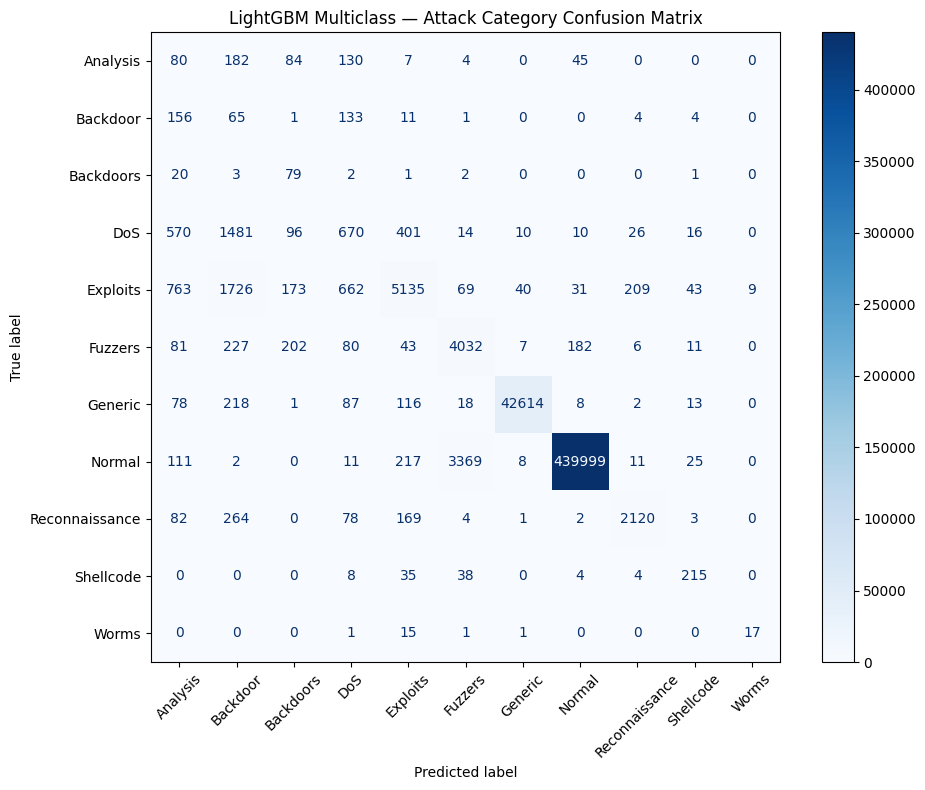


Saving models…
  ✅ xgb_binary_rand.json
  ✅ lgb_binary_rand.txt
  ✅ rf_binary_rand.joblib
  ✅ xgb_binary_time.json
  ✅ lgb_binary_time.txt
  ✅ rf_binary_time.joblib
  ✅ lgb_multiclass.txt
  ✅ mc_label_encoder.joblib
  ✅ feature_columns.joblib

  PIPELINE COMPLETE

  Features              : 59
  Train rows (rand bal) : 3,550,022
  Train rows (time bal) : 3,619,702
  Test rows  (random)   : 508,010
  Test rows  (time)     : 508,010
  Attack categories     : 11

  Models saved to       : /kaggle/working/models/

  Files:
    feature_columns.joblib                            0.7 KB
    lgb_binary_rand.txt                            6775.8 KB
    lgb_binary_time.txt                            6780.7 KB
    lgb_multiclass.txt                            70182.2 KB
    mc_label_encoder.joblib                           0.6 KB
    metrics_summary.csv                               2.0 KB
    rf_binary_rand.joblib                        205123.6 KB
    rf_binary_time.joblib                       

In [2]:
# =============================================================================
# IDS Pipeline — UNSW-NB15
# Phases 12-16: Train → Evaluate → Multiclass → Save → Summary Table
# =============================================================================
# Models trained on BOTH random split and time-based split (both SMOTE-balanced):
#
#   Random split  : xgb_rand, lgb_rand, rf_rand
#   Time split    : xgb_time, lgb_time, rf_time
#
# Evaluation:
#   Phase 13  — random-split models on X_test
#   Phase 14  — time-split models on X_te_time + cross-eval
#   Phase 14b — full summary table of all metrics across all models/splits
#   Phase 15  — multiclass attack category classifier
#   Phase 16  — save all models and artifacts
# =============================================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score

# =============================================================================
# Phase 12 — Binary Classifier Training (XGBoost + LightGBM + Random Forest)
# =============================================================================

def build_val_split(X, y, label=''):
    """Carve a 10% validation set for early stopping feedback."""
    X_fit, X_val, y_fit, y_val = train_test_split(
        X, y, test_size=0.10, stratify=y, random_state=42
    )
    print(f'  [{label}] fit: {X_fit.shape}  |  val: {X_val.shape}')
    return X_fit, X_val, y_fit, y_val


def train_xgb(X_fit, X_val, y_fit, y_val, label=''):
    print(f'\n  Training XGBoost [{label}]…')
    model = xgb.XGBClassifier(
        n_estimators          = 1000,
        learning_rate         = 0.05,
        max_depth             = 6,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        use_label_encoder     = False,
        eval_metric           = 'logloss',
        early_stopping_rounds = 30,
        random_state          = 42,
        n_jobs                = -1,
        verbosity             = 1
    )
    model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=50)
    print(f'  Best iteration: {model.best_iteration}')
    return model


def train_lgb(X_fit, X_val, y_fit, y_val, label=''):
    print(f'\n  Training LightGBM [{label}]…')
    model = lgb.LGBMClassifier(
        n_estimators     = 1000,
        learning_rate    = 0.05,
        max_depth        = -1,
        num_leaves       = 63,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        is_unbalance     = False,
        random_state     = 42,
        n_jobs           = -1,
        verbosity        = -1
    )
    callbacks = [lgb.early_stopping(30, verbose=False), lgb.log_evaluation(50)]
    model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], callbacks=callbacks)
    print(f'  Best iteration: {model.best_iteration_}')
    return model


def train_rf(X_fit, y_fit, label=''):
    # RF does not use early stopping — n_estimators is fixed.
    # 300 trees balances accuracy and training time on 3M+ row datasets.
    # max_depth=20 prevents memory explosion from unlimited-depth trees.
    # SMOTE already balanced the data so class_weight is not needed.
    print(f'\n  Training Random Forest [{label}]…')
    model = RandomForestClassifier(
        n_estimators = 300,
        max_depth    = 20,
        max_features = 'sqrt',
        n_jobs       = -1,
        random_state = 42,
        verbose      = 1
    )
    model.fit(X_fit, y_fit)
    print(f'  RF [{label}] trained.')
    return model


# ── Random-split models ───────────────────────────────────────────────────────
print('=' * 65)
print('  RANDOM SPLIT — XGBoost, LightGBM, Random Forest')
print('=' * 65)

X_tr_r, X_val_r, y_tr_r, y_val_r = build_val_split(
    X_train_bal, y_train_bal, label='random'
)
xgb_rand = train_xgb(X_tr_r, X_val_r, y_tr_r, y_val_r, label='random')
lgb_rand = train_lgb(X_tr_r, X_val_r, y_tr_r, y_val_r, label='random')
rf_rand  = train_rf(X_tr_r, y_tr_r, label='random')

####

# ── Time-split models ─────────────────────────────────────────────────────────
print('\n' + '=' * 65)
print('  TIME SPLIT — XGBoost, LightGBM, Random Forest')
print('=' * 65)

X_tr_t, X_val_t, y_tr_t, y_val_t = build_val_split(
    X_tr_time_bal, y_tr_time_bal, label='time'
)
xgb_time = train_xgb(X_tr_t, X_val_t, y_tr_t, y_val_t, label='time')
lgb_time = train_lgb(X_tr_t, X_val_t, y_tr_t, y_val_t, label='time')
rf_time  = train_rf(X_tr_t, y_tr_t, label='time')

####

# =============================================================================
# Phase 13 — Evaluation Helper
# =============================================================================
def evaluate_model(model, X, y, model_name, split_name):
    """
    Full evaluation: prints classification report + confusion matrix.
    Returns a dict of scalar metrics for the final summary table.
    """
    y_pred   = model.predict(X)
    y_prob   = model.predict_proba(X)[:, 1]

    acc      = accuracy_score(y, y_pred)
    roc_auc  = roc_auc_score(y, y_prob)
    f1_w     = f1_score(y, y_pred, average='weighted')
    f1_mac   = f1_score(y, y_pred, average='macro')
    prec_w   = precision_score(y, y_pred, average='weighted', zero_division=0)
    rec_w    = recall_score(y, y_pred, average='weighted', zero_division=0)

    # Attack-class (class=1) specific metrics — most important for IDS
    prec_atk = precision_score(y, y_pred, pos_label=1, average='binary', zero_division=0)
    rec_atk  = recall_score(y, y_pred, pos_label=1, average='binary', zero_division=0)
    f1_atk   = f1_score(y, y_pred, pos_label=1, average='binary', zero_division=0)

    print(f'\n{"=" * 65}')
    print(f'  {model_name}  |  {split_name}')
    print(f'{"=" * 65}')
    print(f'  Accuracy                  : {acc:.4f}')
    print(f'  ROC-AUC                   : {roc_auc:.4f}')
    print(f'  F1 (weighted)             : {f1_w:.4f}')
    print(f'  F1 (macro)                : {f1_mac:.4f}')
    print(f'  Precision (Attack class)  : {prec_atk:.4f}')
    print(f'  Recall    (Attack class)  : {rec_atk:.4f}')
    print(f'  F1        (Attack class)  : {f1_atk:.4f}')
    print()
    print(classification_report(y, y_pred, target_names=['Normal', 'Attack']))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y, y_pred,
        display_labels=['Normal', 'Attack'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'{model_name}\n{split_name}')
    plt.tight_layout()
    plt.show()

    return {
        'model':         model_name,
        'split':         split_name,
        'accuracy':      acc,
        'roc_auc':       roc_auc,
        'f1_weighted':   f1_w,
        'f1_macro':      f1_mac,
        'precision_w':   prec_w,
        'recall_w':      rec_w,
        'precision_atk': prec_atk,
        'recall_atk':    rec_atk,
        'f1_atk':        f1_atk,
        'y_prob':        y_prob       # kept for PR curves, excluded from summary
    }


####

# =============================================================================
# Phase 13 — Random-split models evaluated on X_test
# =============================================================================
print('\n\n── RANDOM-SPLIT MODELS  →  evaluated on X_test ──────────────────────')

results_rand = []
for model, name in [(xgb_rand, 'XGBoost'),
                    (lgb_rand, 'LightGBM'),
                    (rf_rand,  'RandomForest')]:
    r = evaluate_model(model, X_test, y_test,
                       f'{name} [rand]', 'Random test (X_test)')
    results_rand.append(r)

# Precision-Recall curves
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, r in zip(axes, results_rand):
    prec, rec, _ = precision_recall_curve(y_test, r['y_prob'])
    ax.plot(rec, prec)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(r['model']); ax.grid(True)
plt.suptitle('Precision-Recall — Random-split models on X_test', fontsize=13)
plt.tight_layout()
plt.show()

####

# =============================================================================
# Phase 14 — Time-split models evaluated on X_te_time
# =============================================================================
print('\n\n── TIME-SPLIT MODELS  →  evaluated on X_te_time ─────────────────────')

results_time = []
for model, name in [(xgb_time, 'XGBoost'),
                    (lgb_time, 'LightGBM'),
                    (rf_time,  'RandomForest')]:
    r = evaluate_model(model, X_te_time, y_te_time,
                       f'{name} [time]', 'Time test (X_te_time)')
    results_time.append(r)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, r in zip(axes, results_time):
    prec, rec, _ = precision_recall_curve(y_te_time, r['y_prob'])
    ax.plot(rec, prec)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(r['model']); ax.grid(True)
plt.suptitle('Precision-Recall — Time-split models on X_te_time', fontsize=13)
plt.tight_layout()
plt.show()

####

# ── Cross-evaluation: random-split models on time test ───────────────────────
print('\n\n── CROSS-EVAL: random-split models  →  X_te_time ────────────────────')

results_cross = []
for model, name in [(xgb_rand, 'XGBoost'),
                    (lgb_rand, 'LightGBM'),
                    (rf_rand,  'RandomForest')]:
    r = evaluate_model(model, X_te_time, y_te_time,
                       f'{name} [rand→time]', 'Cross-eval on X_te_time')
    results_cross.append(r)

####

# =============================================================================
# Phase 14b — Full Summary Table
# =============================================================================
all_results = results_rand + results_time + results_cross

metric_cols = ['accuracy', 'roc_auc', 'f1_weighted', 'f1_macro',
               'precision_w', 'recall_w', 'precision_atk', 'recall_atk', 'f1_atk']

summary_rows = [{k: v for k, v in r.items() if k != 'y_prob'} for r in all_results]
summary_df   = pd.DataFrame(summary_rows)

print('\n\n' + '=' * 100)
print('  FULL METRICS SUMMARY TABLE')
print('=' * 100)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)
print(summary_df[['model', 'split'] + metric_cols].to_string(index=False))

# ── Visual heatmap of key metrics ────────────────────────────────────────────
heat_data = summary_df.set_index('model')[metric_cols]
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heat_data.astype(float),
    annot=True, fmt='.4f', cmap='YlGnBu',
    linewidths=0.5, ax=ax, vmin=0.7, vmax=1.0
)
ax.set_title('Metrics Heatmap — All Models & Splits', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

# ── ROC-AUC gap table ─────────────────────────────────────────────────────────
print('\n── ROC-AUC Gap Summary ──────────────────────────────────────────────')
print(f'{"Algorithm":<16}  {"Rand test":>10}  {"Time test":>10}  {"Cross-eval":>11}  {"Gap (r-t)":>10}')
print('-' * 65)

for algo in ['XGBoost', 'LightGBM', 'RandomForest']:
    rand_r  = next(r for r in results_rand  if r['model'].startswith(algo))
    time_r  = next(r for r in results_time  if r['model'].startswith(algo))
    cross_r = next(r for r in results_cross if r['model'].startswith(algo))
    gap     = rand_r['roc_auc'] - time_r['roc_auc']
    print(f'{algo:<16}  {rand_r["roc_auc"]:>10.4f}  {time_r["roc_auc"]:>10.4f}'
          f'  {cross_r["roc_auc"]:>11.4f}  {gap:>+10.4f}')

# Save CSV for use in hyperparameter tuning phase
csv_path = os.path.join(MODEL_DIR, 'metrics_summary.csv')
summary_df[['model', 'split'] + metric_cols].to_csv(csv_path, index=False)
print(f'\n✅ Metrics summary saved → {csv_path}')

####

# =============================================================================
# Phase 15 — Multiclass Classifier (attack category)
# =============================================================================
print('\n\n── Multiclass training ──────────────────────────────────────────────')

mc_label_encoder = LabelEncoder()
y_train_mc_enc   = mc_label_encoder.fit_transform(y_train_mc)
y_test_mc_enc    = mc_label_encoder.transform(y_test_mc)

print('Attack categories:')
for i, cls in enumerate(mc_label_encoder.classes_):
    count = (y_train_mc_enc == i).sum()
    print(f'  {i:>2}: {cls:<20}  train count: {count:,}')

n_classes = len(mc_label_encoder.classes_)

X_mc_tr, X_mc_val, y_mc_tr, y_mc_val = train_test_split(
    X_train, y_train_mc_enc,
    test_size=0.10, stratify=y_train_mc_enc, random_state=42
)

lgb_mc_model = lgb.LGBMClassifier(
    objective        = 'multiclass',
    num_class        = n_classes,
    n_estimators     = 1000,
    learning_rate    = 0.05,
    num_leaves       = 63,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = -1
)

mc_callbacks = [lgb.early_stopping(30, verbose=False), lgb.log_evaluation(50)]
lgb_mc_model.fit(X_mc_tr, y_mc_tr,
                 eval_set=[(X_mc_val, y_mc_val)],
                 callbacks=mc_callbacks)

print(f'Multiclass LightGBM best iteration: {lgb_mc_model.best_iteration_}')

y_mc_pred = lgb_mc_model.predict(X_test)
print('\nMulticlass classification report:')
print(classification_report(y_test_mc_enc, y_mc_pred,
                             target_names=mc_label_encoder.classes_))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test_mc_enc, y_mc_pred,
    display_labels=mc_label_encoder.classes_,
    cmap='Blues', xticks_rotation=45, ax=ax
)
ax.set_title('LightGBM Multiclass — Attack Category Confusion Matrix')
plt.tight_layout()
plt.show()

####

# =============================================================================
# Phase 16 — Save All Models and Artifacts
# =============================================================================
print('\nSaving models…')

def _save_xgb(model, fname):
    path = os.path.join(MODEL_DIR, fname)
    model.save_model(path)
    print(f'  ✅ {fname}')

def _save_lgb(model, fname):
    path = os.path.join(MODEL_DIR, fname)
    model.booster_.save_model(path)
    print(f'  ✅ {fname}')

def _save_jl(obj, fname):
    path = os.path.join(MODEL_DIR, fname)
    joblib.dump(obj, path)
    print(f'  ✅ {fname}')

_save_xgb(xgb_rand,      'xgb_binary_rand.json')
_save_lgb(lgb_rand,      'lgb_binary_rand.txt')
_save_jl(rf_rand,        'rf_binary_rand.joblib')

_save_xgb(xgb_time,      'xgb_binary_time.json')
_save_lgb(lgb_time,      'lgb_binary_time.txt')
_save_jl(rf_time,        'rf_binary_time.joblib')

_save_lgb(lgb_mc_model,  'lgb_multiclass.txt')
_save_jl(mc_label_encoder, 'mc_label_encoder.joblib')
_save_jl(X_train.columns.tolist(), 'feature_columns.joblib')

print('\n' + '=' * 65)
print('  PIPELINE COMPLETE')
print('=' * 65)
print(f'\n  Features              : {X_train.shape[1]}')
print(f'  Train rows (rand bal) : {X_train_bal.shape[0]:,}')
print(f'  Train rows (time bal) : {X_tr_time_bal.shape[0]:,}')
print(f'  Test rows  (random)   : {X_test.shape[0]:,}')
print(f'  Test rows  (time)     : {X_te_time.shape[0]:,}')
print(f'  Attack categories     : {n_classes}')
print(f'\n  Models saved to       : {MODEL_DIR}')
print('\n  Files:')
for fname in sorted(os.listdir(MODEL_DIR)):
    fpath = os.path.join(MODEL_DIR, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f'    {fname:<44} {size:>8.1f} KB')

In [ ]:
# =============================================================================
# IDS Pipeline — UNSW-NB15
# Phase 17 — Hyperparameter Tuning with RandomizedSearchCV
# =============================================================================
# This phase reads the metrics_summary.csv produced in Phase 14b to identify
# the best-performing model and split regime, then runs RandomizedSearchCV to
# find better hyperparameters.
#
# Why RandomizedSearch over GridSearch?
#   - GridSearch evaluates EVERY combination: with 5 params × 4 values = 1024 fits
#   - RandomizedSearch samples n_iter random combinations: far faster on large data
#   - Research shows random search finds near-optimal configs in far fewer trials
#     (Bergstra & Bengio 2012)
#
# Strategy:
#   1. Read summary CSV → pick best model by ROC-AUC on time test
#      (time test = harder, more realistic → best model there is most deployable)
#   2. Run RandomizedSearchCV with StratifiedKFold on that model family
#   3. Re-evaluate tuned model on all test sets
#   4. Compare tuned vs baseline metrics side by side
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import randint, uniform

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score, precision_recall_curve
)

import xgboost as xgb
import lightgbm as lgb

MODEL_DIR = '/kaggle/working/models/'

# =============================================================================
# Step 1 — Identify best model from summary
# =============================================================================
# We rank by ROC-AUC on the time-based test set because:
#   - Time test is the harder, more realistic evaluation
#   - Best model there is the one most likely to generalise to new traffic
#   - ROC-AUC is threshold-independent — better than accuracy for IDS

summary_path = os.path.join(MODEL_DIR, 'metrics_summary.csv')
summary_df   = pd.read_csv(summary_path)

print('Loaded metrics summary:')
print(summary_df[['model', 'split', 'roc_auc', 'f1_atk', 'recall_atk']].to_string(index=False))

# Filter to time-test rows only (excludes cross-eval and random-test rows)
time_rows = summary_df[summary_df['split'].str.contains('Time test')]
best_row  = time_rows.loc[time_rows['roc_auc'].idxmax()]

print(f'\n✅ Best model on time test: {best_row["model"]}')
print(f'   ROC-AUC : {best_row["roc_auc"]:.4f}')
print(f'   F1 (atk): {best_row["f1_atk"]:.4f}')
print(f'   Recall  : {best_row["recall_atk"]:.4f}')

# Determine which algorithm and which training set to use
best_model_name = best_row['model']   # e.g. 'LightGBM [time]'
use_time_split  = '[time]' in best_model_name
is_xgb          = 'XGBoost' in best_model_name
is_lgb          = 'LightGBM' in best_model_name

X_tune = X_tr_time_bal if use_time_split else X_train_bal
y_tune = y_tr_time_bal if use_time_split else y_train_bal

print(f'\n  Tuning on : {"time-split SMOTE-balanced" if use_time_split else "random-split SMOTE-balanced"}')
print(f'  Rows      : {X_tune.shape[0]:,}')

####

# =============================================================================
# Step 2 — Subsample for tuning speed
# =============================================================================
# RandomizedSearchCV with 5-fold CV on 3M rows is extremely slow.
# We use a stratified subsample of 20% for tuning — large enough to be
# representative, small enough to complete in reasonable time.
# The final tuned model is then re-trained on the full training set.

from sklearn.model_selection import train_test_split

TUNE_FRAC = 0.20
X_tune_sub, _, y_tune_sub, _ = train_test_split(
    X_tune, y_tune,
    train_size=TUNE_FRAC,
    stratify=y_tune,
    random_state=42
)

print(f'\nTuning subsample: {X_tune_sub.shape[0]:,} rows  '
      f'({TUNE_FRAC:.0%} of {X_tune.shape[0]:,})')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

####

# =============================================================================
# Step 3 — RandomizedSearchCV
# =============================================================================
# Parameter grids are intentionally broad on the first pass.
# After seeing results, you can narrow the ranges around the best values.

N_ITER = 30   # number of random parameter combinations to try

if is_lgb:
    print('\nRunning RandomizedSearchCV for LightGBM…')

    base_model = lgb.LGBMClassifier(
        objective    = 'binary',
        random_state = 42,
        n_jobs       = -1,
        verbosity    = -1
    )

    param_dist = {
        'n_estimators':     randint(200, 1200),
        'learning_rate':    uniform(0.01, 0.15),     # 0.01 – 0.16
        'num_leaves':       randint(31, 256),
        'max_depth':        randint(5, 20),
        'subsample':        uniform(0.6, 0.4),        # 0.6 – 1.0
        'colsample_bytree': uniform(0.6, 0.4),
        'min_child_samples': randint(10, 100),
        'reg_alpha':        uniform(0.0, 1.0),        # L1 regularisation
        'reg_lambda':       uniform(0.0, 1.0),        # L2 regularisation
    }

elif is_xgb:
    print('\nRunning RandomizedSearchCV for XGBoost…')

    base_model = xgb.XGBClassifier(
        use_label_encoder = False,
        eval_metric       = 'logloss',
        random_state      = 42,
        n_jobs            = -1,
        verbosity         = 0
    )

    param_dist = {
        'n_estimators':    randint(200, 1200),
        'learning_rate':   uniform(0.01, 0.15),
        'max_depth':       randint(3, 12),
        'subsample':       uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'gamma':           uniform(0.0, 0.5),         # min split loss
        'reg_alpha':       uniform(0.0, 1.0),
        'reg_lambda':      uniform(0.5, 2.0),
        'min_child_weight': randint(1, 10),
    }

else:
    raise ValueError(f'Unexpected model type: {best_model_name}')


search = RandomizedSearchCV(
    estimator          = base_model,
    param_distributions = param_dist,
    n_iter             = N_ITER,
    scoring            = 'roc_auc',     # optimise for ROC-AUC
    cv                 = cv,
    n_jobs             = -1,
    random_state       = 42,
    verbose            = 2,
    refit              = True           # refit best params on full subsample
)

search.fit(X_tune_sub, y_tune_sub)

print(f'\n✅ RandomizedSearch complete.')
print(f'   Best ROC-AUC (CV on subsample): {search.best_score_:.4f}')
print(f'\n   Best parameters:')
for k, v in sorted(search.best_params_.items()):
    print(f'     {k:<25}: {v}')

####

# =============================================================================
# Step 4 — Re-train best params on full training set
# =============================================================================
# The search was done on a 20% subsample for speed.
# Now we re-train a fresh model with the best found parameters on the full
# training data to get the strongest possible model.

print(f'\nRe-training on full training set ({X_tune.shape[0]:,} rows)…')

best_params = search.best_params_

if is_lgb:
    tuned_model = lgb.LGBMClassifier(
        **best_params,
        objective    = 'binary',
        random_state = 42,
        n_jobs       = -1,
        verbosity    = -1
    )
else:
    tuned_model = xgb.XGBClassifier(
        **best_params,
        use_label_encoder = False,
        eval_metric       = 'logloss',
        random_state      = 42,
        n_jobs            = -1,
        verbosity         = 0
    )

tuned_model.fit(X_tune, y_tune)
print('Re-training complete.')

####

# =============================================================================
# Step 5 — Evaluate tuned model
# =============================================================================
def full_eval(model, X, y, title):
    """Evaluate a model and return a metrics dict."""
    y_pred   = model.predict(X)
    y_prob   = model.predict_proba(X)[:, 1]

    acc      = accuracy_score(y, y_pred)
    roc_auc  = roc_auc_score(y, y_prob)
    f1_w     = f1_score(y, y_pred, average='weighted')
    f1_mac   = f1_score(y, y_pred, average='macro')
    prec_atk = precision_score(y, y_pred, pos_label=1, average='binary', zero_division=0)
    rec_atk  = recall_score(y, y_pred, pos_label=1, average='binary', zero_division=0)
    f1_atk   = f1_score(y, y_pred, pos_label=1, average='binary', zero_division=0)

    print(f'\n{"=" * 65}')
    print(f'  {title}')
    print(f'{"=" * 65}')
    print(f'  Accuracy            : {acc:.4f}')
    print(f'  ROC-AUC             : {roc_auc:.4f}')
    print(f'  F1 weighted         : {f1_w:.4f}')
    print(f'  F1 macro            : {f1_mac:.4f}')
    print(f'  Precision (Attack)  : {prec_atk:.4f}')
    print(f'  Recall    (Attack)  : {rec_atk:.4f}')
    print(f'  F1        (Attack)  : {f1_atk:.4f}')
    print()
    print(classification_report(y, y_pred, target_names=['Normal', 'Attack']))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y, y_pred,
        display_labels=['Normal', 'Attack'],
        cmap='Greens', ax=ax
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return {
        'title': title, 'accuracy': acc, 'roc_auc': roc_auc,
        'f1_weighted': f1_w, 'f1_macro': f1_mac,
        'precision_atk': prec_atk, 'recall_atk': rec_atk, 'f1_atk': f1_atk,
        'y_prob': y_prob
    }


# Evaluate tuned model on both test sets
tuned_rand = full_eval(tuned_model, X_test,    y_test,    'Tuned model — Random test (X_test)')
tuned_time = full_eval(tuned_model, X_te_time, y_te_time, 'Tuned model — Time test  (X_te_time)')

####

# =============================================================================
# Step 6 — Baseline vs Tuned comparison
# =============================================================================
# Load the baseline metrics for the same model/split from the summary CSV
baseline_time_row = time_rows[time_rows['model'] == best_model_name].iloc[0]
baseline_rand_row = summary_df[
    (summary_df['model'] == best_model_name.replace('[time]', '[rand]').replace('[rand]', '[rand]')) &
    (summary_df['split'].str.contains('Random test'))
]

metric_cols = ['accuracy', 'roc_auc', 'f1_weighted', 'f1_macro',
               'precision_atk', 'recall_atk', 'f1_atk']

compare_rows = []

# Baseline — random test
if not baseline_rand_row.empty:
    b_rand = baseline_rand_row.iloc[0]
    compare_rows.append({
        'version': f'Baseline {best_model_name} — Random test',
        **{c: b_rand[c] for c in metric_cols}
    })

# Baseline — time test
compare_rows.append({
    'version': f'Baseline {best_model_name} — Time test',
    **{c: baseline_time_row[c] for c in metric_cols}
})

# Tuned — random test
compare_rows.append({
    'version': 'Tuned — Random test',
    **{c: tuned_rand[c] for c in metric_cols}
})

# Tuned — time test
compare_rows.append({
    'version': 'Tuned — Time test',
    **{c: tuned_time[c] for c in metric_cols}
})

compare_df = pd.DataFrame(compare_rows).set_index('version')

print('\n\n' + '=' * 90)
print('  BASELINE vs TUNED — Side-by-side Comparison')
print('=' * 90)
pd.set_option('display.float_format', '{:.4f}'.format)
print(compare_df[metric_cols].to_string())

# Delta row: tuned time - baseline time
delta = compare_df.loc['Tuned — Time test'] - compare_df.loc[f'Baseline {best_model_name} — Time test']
print(f'\nDelta (Tuned time − Baseline time):')
for col in metric_cols:
    sign = '+' if delta[col] >= 0 else ''
    print(f'  {col:<20}: {sign}{delta[col]:.4f}')

####

# Precision-Recall comparison plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (y_true, prob_base, prob_tune, title) in zip(
    axes,
    [
        (y_test,    results_rand[0 if is_xgb else 1]['y_prob'], tuned_rand['y_prob'], 'Random test'),
        (y_te_time, results_time[0 if is_xgb else 1]['y_prob'], tuned_time['y_prob'], 'Time test'),
    ]
):
    p_b, r_b, _ = precision_recall_curve(y_true, prob_base)
    p_t, r_t, _ = precision_recall_curve(y_true, prob_tune)
    ax.plot(r_b, p_b, label='Baseline', linestyle='--')
    ax.plot(r_t, p_t, label='Tuned')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'PR Curve — {title}')
    ax.legend(); ax.grid(True)

plt.suptitle(f'Baseline vs Tuned: {best_model_name}', fontsize=13)
plt.tight_layout()
plt.show()

####

# =============================================================================
# Step 7 — Save tuned model and search results
# =============================================================================
print('\nSaving tuned model and search results…')

# Save the tuned model
tuned_fname = f'tuned_{"lgb" if is_lgb else "xgb"}_{"time" if use_time_split else "rand"}'

if is_lgb:
    tuned_path = os.path.join(MODEL_DIR, f'{tuned_fname}.txt')
    tuned_model.booster_.save_model(tuned_path)
else:
    tuned_path = os.path.join(MODEL_DIR, f'{tuned_fname}.json')
    tuned_model.save_model(tuned_path)

print(f'  ✅ Tuned model → {tuned_path}')

# Save best params
params_path = os.path.join(MODEL_DIR, f'{tuned_fname}_best_params.joblib')
joblib.dump(best_params, params_path)
print(f'  ✅ Best params → {params_path}')

# Save CV results as CSV for analysis
cv_results_df = pd.DataFrame(search.cv_results_)
cv_path       = os.path.join(MODEL_DIR, f'{tuned_fname}_cv_results.csv')
cv_results_df.to_csv(cv_path, index=False)
print(f'  ✅ CV results  → {cv_path}')

# Save comparison table
compare_path = os.path.join(MODEL_DIR, 'baseline_vs_tuned.csv')
compare_df[metric_cols].to_csv(compare_path)
print(f'  ✅ Comparison  → {compare_path}')

####

# ── CV results plot: distribution of ROC-AUC across all trials ───────────────
plt.figure(figsize=(10, 4))
plt.plot(range(1, N_ITER + 1),
         cv_results_df['mean_test_score'].values,
         marker='o', markersize=4)
plt.axhline(search.best_score_, color='red', linestyle='--',
            label=f'Best: {search.best_score_:.4f}')
plt.xlabel('Trial')
plt.ylabel('Mean CV ROC-AUC')
plt.title('RandomizedSearchCV — ROC-AUC per Trial')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('\n✅ Phase 17 complete.')
print(f'   Best CV ROC-AUC (subsample) : {search.best_score_:.4f}')
print(f'   Tuned ROC-AUC (random test) : {tuned_rand["roc_auc"]:.4f}')
print(f'   Tuned ROC-AUC (time test)   : {tuned_time["roc_auc"]:.4f}')

Loaded metrics summary:
                   model                   split  roc_auc  f1_atk  recall_atk
          XGBoost [rand]    Random test (X_test)   0.9998  0.9781      0.9811
         LightGBM [rand]    Random test (X_test)   0.9998  0.9809      0.9815
     RandomForest [rand]    Random test (X_test)   0.9998  0.9767      0.9864
          XGBoost [time]   Time test (X_te_time)   0.9995  0.9689      0.9830
         LightGBM [time]   Time test (X_te_time)   0.9995  0.9695      0.9810
     RandomForest [time]   Time test (X_te_time)   0.9990  0.9691      0.9882
     XGBoost [rand→time] Cross-eval on X_te_time   0.9994  0.9658      0.9952
    LightGBM [rand→time] Cross-eval on X_te_time   0.9997  0.9736      0.9954
RandomForest [rand→time] Cross-eval on X_te_time   0.9998  0.9811      0.9938

✅ Best model on time test: LightGBM [time]
   ROC-AUC : 0.9995
   F1 (atk): 0.9695
   Recall  : 0.9810

  Tuning on : time-split SMOTE-balanced
  Rows      : 3,619,702

Tuning subsample: 723,940 